# 01 — EDA: Goodreads Book Recommender

Exploratory analysis on the real preprocessed artifacts (`artifacts/sample.parquet` — 50k-user interactions; `artifacts/catalog.parquet` — surviving books). Covers rating distribution, interactions per user/book, matrix sparsity, description length, shelf/genre signal, language mix, temporal spread, and anomalies.

In [2]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
def find(name):
    for pat in (f'artifacts/{name}', f'../artifacts/{name}',
                f'/kaggle/input/**/{name}', f'/kaggle/working/**/{name}'):
        hits = glob.glob(pat, recursive=True)
        if hits:
            return hits[0]
    raise FileNotFoundError(name)

sample = pd.read_parquet(find('sample.parquet'))
catalog = pd.read_parquet(find('catalog.parquet'))
print('sample:', sample.shape, '| catalog:', catalog.shape)

sample: (12618544, 4) | catalog: (468628, 9)


In [4]:
catalog.head()

,book_id,title,description,language_code,shelves,author_id,author,work_id,image_url
0,7327624,"The Unschooled Wizard (Sun Wolf and Starhawk, ...",Omnibus book club edition containing the Ladie...,eng,"[to-read, fantasy, fiction, owned, hardcover]",10333,Barbara Hambly,8948723,https://images.gr-assets.com/books/1304100136m...
1,6066814,"Crowner Royal (Crowner John Mystery, #13)","London, 1196. At the command of Richard the Li...",,"[to-read, historical-fiction, mystery, histori...",37778,Bernard Knight,6243149,https://images.gr-assets.com/books/1328724803m...
2,33394837,The House of Memory (Pluto's Snitch #2),,eng,"[currently-reading, netgalley, kindle, read-20...",242185,Carolyn Haines,54143148,https://images.gr-assets.com/books/1493114742m...
3,89377,Penny from Heaven,It's 1953 and 11-year-old Penny dreams of a su...,,"[to-read, historical-fiction, currently-readin...",137561,Jennifer L. Holm,86258,https://images.gr-assets.com/books/1320470906m...
4,89378,Dog Heaven,In Newbery Medalist Cynthia Rylant's classic b...,eng,"[to-read, picture-books, animals, children-s-b...",5411,Cynthia Rylant,86259,https://images.gr-assets.com/books/1360057676m...


## Overview

In [5]:
print('interactions:', f'{len(sample):,}')
print('users:', sample.user_id.nunique(), '| books interacted:', sample.book_id.nunique())
print('catalog books:', f'{len(catalog):,}')
display(sample.head())
display(catalog.head())

interactions: 12,618,544
users: 50000 | books interacted: 468628
catalog books: 468,628


,user_id,book_id,rating,timestamp
0,d889b42d9eb7b80e02f24830e27c6389,196084,3,978336000
1,56771a556632bb4465cab31e5ab5ad81,285205,4,979027200
2,d889b42d9eb7b80e02f24830e27c6389,79030,3,979200000
3,d889b42d9eb7b80e02f24830e27c6389,442783,4,980409600
4,d889b42d9eb7b80e02f24830e27c6389,552719,2,980755200


,book_id,title,description,language_code,shelves,author_id,author,work_id,image_url
0,7327624,"The Unschooled Wizard (Sun Wolf and Starhawk, ...",Omnibus book club edition containing the Ladie...,eng,"[to-read, fantasy, fiction, owned, hardcover]",10333,Barbara Hambly,8948723,https://images.gr-assets.com/books/1304100136m...
1,6066814,"Crowner Royal (Crowner John Mystery, #13)","London, 1196. At the command of Richard the Li...",,"[to-read, historical-fiction, mystery, histori...",37778,Bernard Knight,6243149,https://images.gr-assets.com/books/1328724803m...
2,33394837,The House of Memory (Pluto's Snitch #2),,eng,"[currently-reading, netgalley, kindle, read-20...",242185,Carolyn Haines,54143148,https://images.gr-assets.com/books/1493114742m...
3,89377,Penny from Heaven,It's 1953 and 11-year-old Penny dreams of a su...,,"[to-read, historical-fiction, currently-readin...",137561,Jennifer L. Holm,86258,https://images.gr-assets.com/books/1320470906m...
4,89378,Dog Heaven,In Newbery Medalist Cynthia Rylant's classic b...,eng,"[to-read, picture-books, animals, children-s-b...",5411,Cynthia Rylant,86259,https://images.gr-assets.com/books/1360057676m...


## Rating distribution
0 = shelved/read but not explicitly rated (implicit feedback).

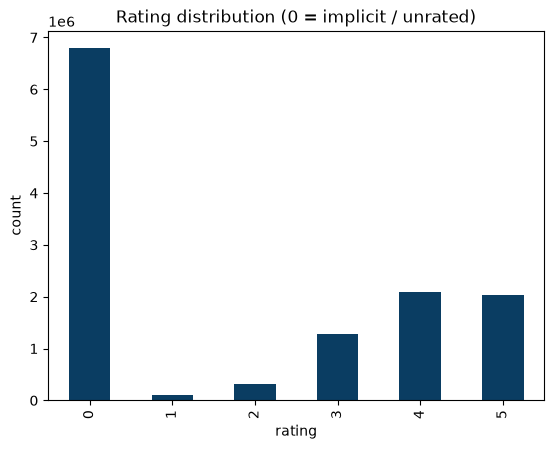

implicit (rating=0) share: 53.8%
explicit (1-5) interactions: 5,829,111


In [6]:
rc = sample.rating.value_counts().sort_index()
ax = rc.plot.bar(color='#0a3d62')
ax.set_title('Rating distribution (0 = implicit / unrated)'); ax.set_xlabel('rating'); ax.set_ylabel('count')
plt.show()
print('implicit (rating=0) share: %.1f%%' % (100*rc.get(0,0)/rc.sum()))
print('explicit (1-5) interactions: %s' % f'{int(rc.loc[1:].sum()):,}')

## Interactions per user

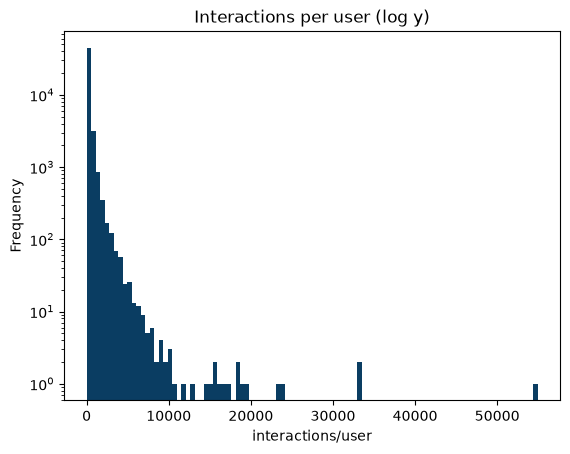

count    50000.0
mean       252.4
std        651.2
min         11.0
25%         47.0
50%        104.0
75%        246.0
max      54923.0


In [7]:
ipu = sample.groupby('user_id').size()
ipu.plot.hist(bins=100, log=True, color='#0a3d62')
plt.title('Interactions per user (log y)'); plt.xlabel('interactions/user'); plt.show()
print(ipu.describe().round(1).to_string())

### Heavy tail → history cap for sequential models

The distribution is extremely right-skewed — **mean ≫ median**, and the busiest user has
tens of thousands of interactions. A handful of power users hold a disproportionate share.
For **SASRec** we therefore **cap each user's history to their most recent N (=100)**: it
removes the RAM and training-time bloat from the tail without losing anything the model uses
(SASRec attends only to the last ~50 items). Together with user subsampling, this is what
shrinks the RecBole training set — e.g. **12.6M → ~2.3M interactions** on a 30k-user sample.

In [8]:
# Heavy tail -> why sequential models cap each user's history (our MAX_HIST in 06_recbole).
CAP = 100
total, kept = int(ipu.sum()), int(ipu.clip(upper=CAP).sum())
print(f"per-user: median {ipu.median():.0f} | mean {ipu.mean():.0f} | "
      f"p90 {ipu.quantile(.9):.0f} | p99 {ipu.quantile(.99):.0f} | max {ipu.max():,}")
print(f"users with > {CAP} interactions: {(ipu > CAP).mean():.1%}")
print(f"capping each user to their last {CAP}: {total:,} -> {kept:,} interactions "
      f"({1 - kept / total:.0%} removed -- almost all from the heavy tail)")

per-user: median 104 | mean 252 | p90 555 | p99 2316 | max 54,923
users with > 100 interactions: 51.1%
capping each user to their last 100: 12,618,544 -> 3,791,145 interactions (70% removed -- almost all from the heavy tail)


## Interactions per book (popularity long tail)

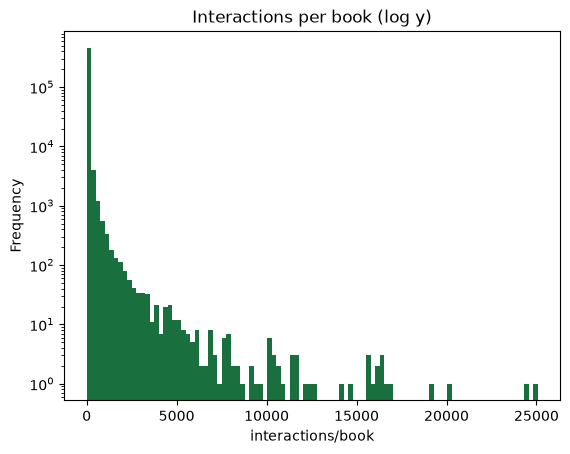

count    468628.0
mean         26.9
std         195.8
min           1.0
25%           2.0
50%           5.0
75%          14.0
max       25065.0
most-read book appears in 25065 sampled users


In [9]:
ipb = sample.groupby('book_id').size()
ipb.plot.hist(bins=100, log=True, color='#196f3d')
plt.title('Interactions per book (log y)'); plt.xlabel('interactions/book'); plt.show()
print(ipb.describe().round(1).to_string())
print('most-read book appears in', ipb.max(), 'sampled users')

## User–book matrix sparsity

In [10]:
n_u, n_b = sample.user_id.nunique(), sample.book_id.nunique()
density = len(sample)/(n_u*n_b)
print(f'users={n_u:,}  books={n_b:,}  interactions={len(sample):,}')
print(f'matrix density = {100*density:.4f}%   (sparsity = {1-density:.5f})')

users=50,000  books=468,628  interactions=12,618,544
matrix density = 0.0539%   (sparsity = 0.99946)


## Synopsis (description) length

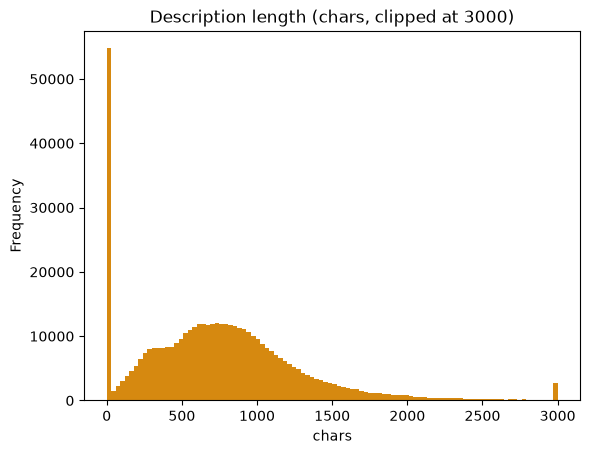

count    468628.0
mean        753.0
std         569.0
min           0.0
25%         373.0
50%         713.0
75%        1029.0
max       27051.0
empty descriptions: 53,957 (11.5%)


In [11]:
dl = catalog.description.fillna('').str.len()
dl.clip(upper=3000).plot.hist(bins=100, color='#d68910')
plt.title('Description length (chars, clipped at 3000)'); plt.xlabel('chars'); plt.show()
print(dl.describe().round(0).to_string())
print('empty descriptions:', f'{(dl==0).sum():,}', '(%.1f%%)' % (100*(dl==0).mean()))

## Shelf / genre signal (top tags)

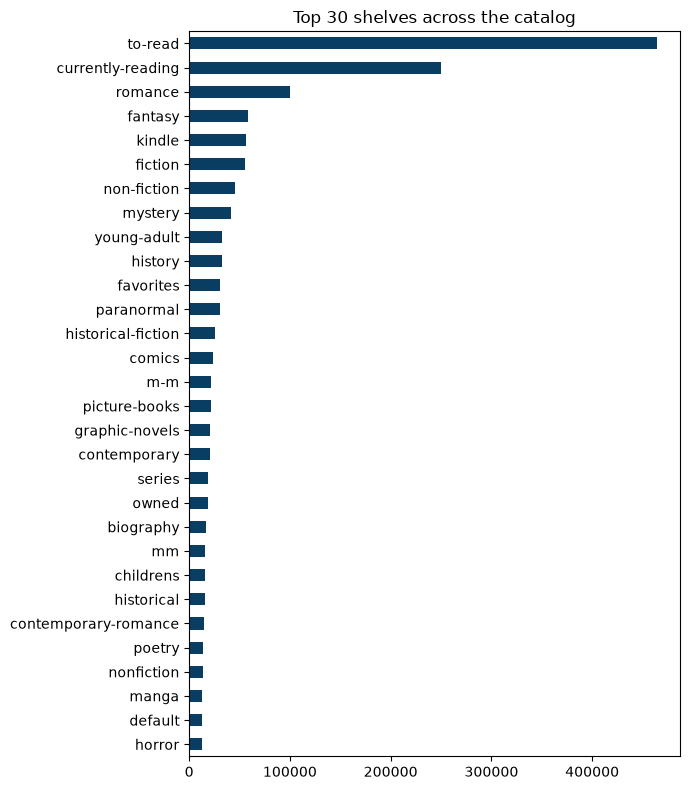

In [12]:
sc = Counter()
for s in catalog['shelves']:
    sc.update(list(s))
top = pd.Series(dict(sc.most_common(30)))
top.iloc[::-1].plot.barh(figsize=(7, 8), color='#0a3d62')
plt.title('Top 30 shelves across the catalog'); plt.tight_layout(); plt.show()

## Language mix
Note: the preprocess did **not** filter to English — non-English books are present.

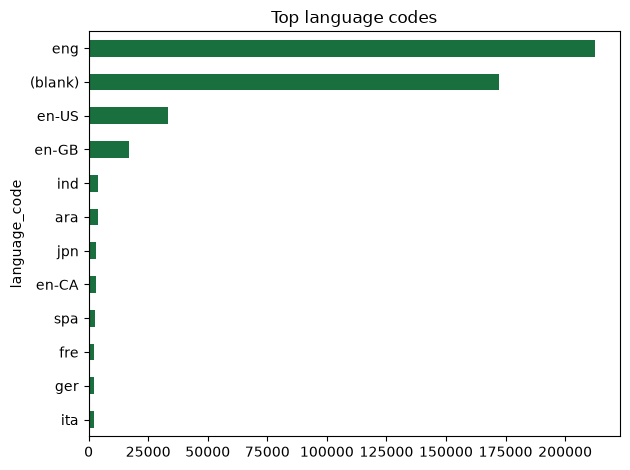

English-or-blank share: 93.5%


In [13]:
lc = catalog.language_code.replace('', '(blank)').value_counts().head(12)
lc.iloc[::-1].plot.barh(color='#196f3d')
plt.title('Top language codes'); plt.tight_layout(); plt.show()
eng = catalog.language_code.isin(['eng','en-US','en-GB','en-CA','en',''])
print('English-or-blank share: %.1f%%' % (100*eng.mean()))

## Temporal spread

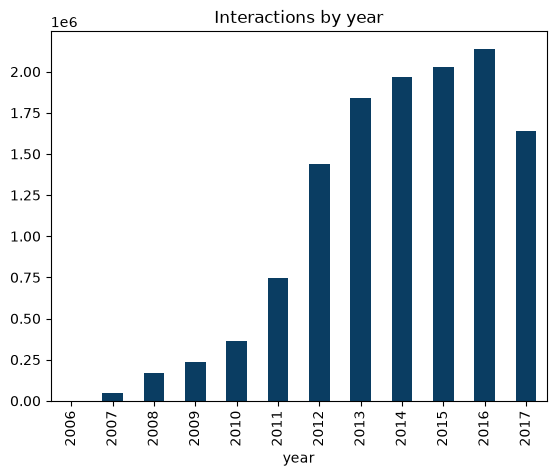

In [14]:
year = pd.to_datetime(sample.timestamp, unit='s').dt.year
year[year >= 2006].value_counts().sort_index().plot.bar(color='#0a3d62')
plt.title('Interactions by year'); plt.xlabel('year'); plt.show()

## Which book fields predict liking? (feature importance)

Target = each book's **like-rate** = P(rating ≥ 4) among its explicit ratings (books with ≥ 20 ratings). Features = book metadata (author track record, genre/shelf tags, popularity, title / description / series / language). A gradient-boosted tree predicts like-rate and **permutation importance** ranks the fields. *(Book-level “broadly liked”, not personalized taste; correlational.)*

**How it's computed**
1. **Target** — for each book, `like_rate = P(rating ≥ 4)` over its *explicit* ratings (1–5; the ~54% rating-0 implicit rows are dropped). Keep books with ≥ 20 ratings so the rate is stable (n ≈ 39k).
2. **Features** (one row per book): `log_popularity` = log(1 + #interactions); `desc_words` / `has_desc`; `title_words`; `is_series` (title contains `#`); `n_shelves`; `english`; `author_n_books`; `author_mean_like` = the author's *other* books' mean like-rate (**leave-one-out** — so a book's own rating can't leak into its own feature); and 1/0 dummies for the 10 most common shelf tags (`genre:*`).
3. **Model** — `HistGradientBoostingRegressor` on a 75/25 train/test split; report holdout R².
4. **Importance** — **permutation** importance (not the tree's built-in, which is biased toward high-cardinality features): on the holdout, shuffle one feature's column and measure the drop in R², averaged over 5 repeats. A bigger drop = the model relied on it more — that R²-drop is what the bars show.

**Findings** (holdout R² ≈ 0.35 — metadata explains ~a third of like-rate variance):
- **Author dominates** — `author_mean_like` (the author's *other* books' like-rate, leave-one-out) is ~13× any other feature. *Who wrote it* predicts liking far more than anything else (strong but partly tautological: good authors write well-liked books).
- **Popularity is a *minor* predictor** (`log_popularity` ≈ 0.03) — liked ≠ popular; bestsellers aren't much more liked than niche books (why a popularity baseline is weak on the fair eval).
- **Genre has small but real signal** — fiction / young-adult / romance / mystery nudge like-rate, far below author.
- **Description, shelf-count, language ≈ 0** — having a synopsis or many shelves doesn't predict *liking* (note: those DO matter for content-based *retrieval* — see the UC4 field ablation — just not for like-rate).

→ For the recommender: the **author signal is the biggest lever** (motivates author-enriched embeddings); genre is weak; description presence is irrelevant to liking.

books=39,468 | holdout R2=0.347 | like_rate mean=0.692
author_mean_like           0.4957
author_n_books             0.0370
log_popularity             0.0302
genre:fiction              0.0202
genre:young-adult          0.0188
genre:kindle               0.0164
title_words                0.0121
is_series                  0.0105
genre:romance              0.0084
genre:mystery              0.0070
desc_words                 0.0050
genre:fantasy              0.0050
genre:history              0.0025
genre:currently-reading    0.0019
english                    0.0016
genre:non-fiction          0.0015
genre:to-read              0.0001
n_shelves                  0.0000
has_desc                   0.0000


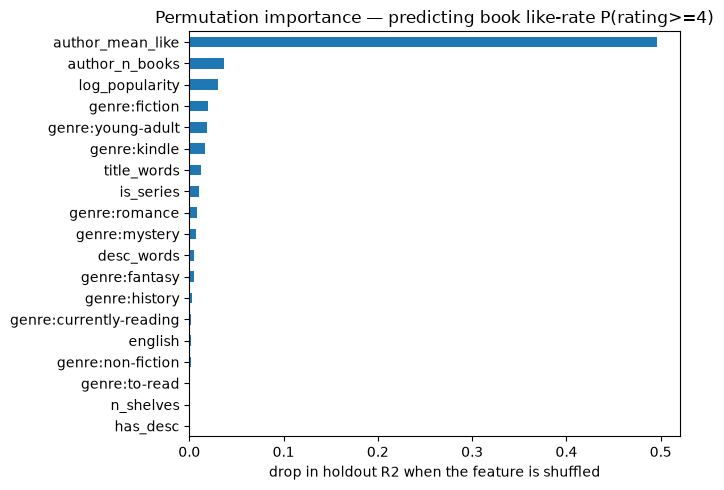

In [15]:
# --- Which book fields predict a book being liked? (book-level feature importance) ---
from collections import Counter
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

MIN_RATINGS = 20
expl = sample[sample.rating >= 1]                                    # explicit ratings only
n_ratings = expl.groupby("book_id").size()
like = expl.assign(l=(expl.rating >= 4)).groupby("book_id").l.mean()  # like-rate = P(rating>=4)
pop = sample.groupby("book_id").size()
keep = n_ratings[n_ratings >= MIN_RATINGS].index
cat = catalog[catalog.book_id.isin(keep)].set_index("book_id")
isl = lambda s: isinstance(s, (list, np.ndarray))
top_genres = [t for t, _ in Counter(x for sh in catalog.shelves if isl(sh) for x in sh).most_common(10)]

f = pd.DataFrame(index=cat.index)
f["like_rate"] = like.reindex(f.index)
f["log_popularity"] = np.log1p(pop.reindex(f.index).fillna(0))
desc = cat.description.fillna("").astype(str)
f["desc_words"] = desc.str.split().str.len()
f["has_desc"] = (f.desc_words > 0).astype(int)
f["title_words"] = cat.title.fillna("").astype(str).str.split().str.len()
f["is_series"] = cat.title.fillna("").astype(str).str.contains("#").astype(int)
f["n_shelves"] = cat.shelves.apply(lambda s: len(s) if isl(s) else 0)
f["english"] = cat.language_code.fillna("").astype(str).str.lower().str.startswith("en").astype(int)
f["author"] = cat.author.fillna("").values
ga = f.groupby("author").like_rate
f["author_n_books"] = ga.transform("size")
f["author_mean_like"] = (ga.transform("sum") - f.like_rate) / (ga.transform("size") - 1)  # leave-one-out
for t in top_genres:
    f[f"genre:{t}"] = cat.shelves.apply(lambda s: int(t in s) if isl(s) else 0)
f = f.drop(columns="author")

X, y = f.drop(columns="like_rate"), f.like_rate
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42)
model = HistGradientBoostingRegressor(random_state=42).fit(Xtr, ytr)
print(f"books={len(f):,} | holdout R2={model.score(Xte, yte):.3f} | like_rate mean={y.mean():.3f}")
imp = permutation_importance(model, Xte, yte, n_repeats=5, random_state=42)
importance = pd.Series(imp.importances_mean, index=X.columns).sort_values()
importance.plot.barh(figsize=(7, 5))
plt.title("Permutation importance \u2014 predicting book like-rate P(rating>=4)")
plt.xlabel("drop in holdout R2 when the feature is shuffled"); plt.tight_layout()
print(importance.sort_values(ascending=False).round(4).to_string())

## Are shelves noise? (genre signal vs behavioural tags)

Goodreads shelves mix real genres (`fantasy`, `romance`) with **behavioural/status** tags (`to-read`, `currently-reading`, `favorites`, `owned`) and **formats** (`kindle`, `ebook`). We feed the top shelves into the book-embedding document ("Themes/shelves") and used them as genre features, so we measure how much is noise: each shelf's **ubiquity** (% of books carrying it) and the **noise fraction** of all shelf occurrences (a transparent hand-labelled stop-list of status/format/meta tags).

**Findings:**
- **`to-read` is on 99% of books, `currently-reading` on 53%** — near-ubiquitous, so they carry *zero* discriminative signal yet fill ~1.5 of every book's 5 shelf slots.
- **37.7% of all shelf occurrences are behavioural/format noise** (1.89 of 5 per book) — over a third of the "Themes/shelves" text we embed is content-free.
- Explains why `n_shelves` scored ~0 in the like-rate importance above: every book has ~5 shelves, mostly the same noise.

→ **Implication:** strip the stop-list before embedding (drop `to-read` / `currently-reading` / `favorites` / `owned` / formats / `series`) to sharpen the genre signal in the content embedding — the genre ablation shows shelves help UC4, likely more once cleaned. A curated `genre` field (the deferred `+genre` ablation) is the rigorous version.

shelf occurrences: 2,342,779 (5.00/book) | unique shelves: 58,611
behavioural/format NOISE: 37.7% of all tags (1.89 of 5.00 per book)


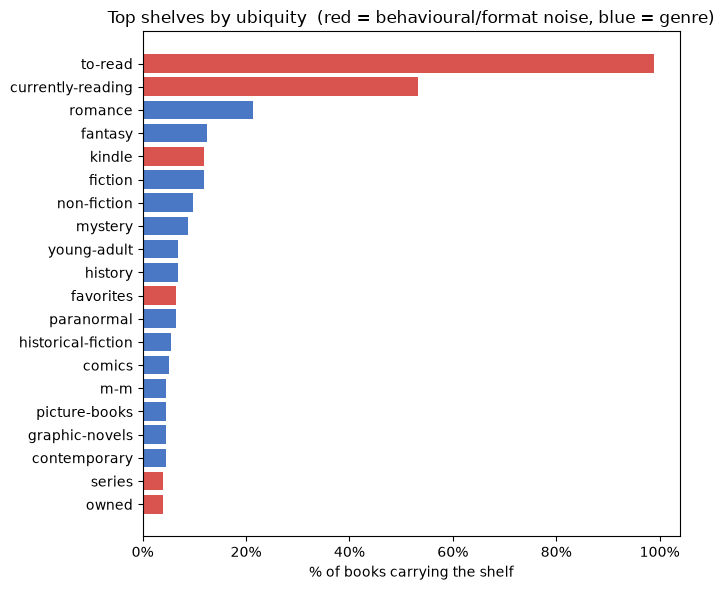

In [16]:
# --- Are shelves genre signal or behavioural noise? ---
isl = lambda s: isinstance(s, (list, np.ndarray))
occ, docf = Counter(), Counter()
for sh in catalog.shelves:
    if isl(sh):
        for t in sh:
            occ[t] += 1
        for t in set(sh):
            docf[t] += 1
total, n = sum(occ.values()), len(catalog)

# transparent stop-list: status / format / meta tags that aren't genres
NOISE = {"to-read", "currently-reading", "favorites", "owned", "default", "series", "read",
         "to-buy", "wish-list", "wishlist", "library", "dnf", "re-read", "reread", "my-books",
         "books-i-own", "owned-books", "my-library", "kindle", "ebook", "e-book", "audiobook",
         "audiobooks", "audio", "paperback", "hardcover", "nook"}
noise_occ = sum(c for t, c in occ.items() if t in NOISE)
print(f"shelf occurrences: {total:,} ({total/n:.2f}/book) | unique shelves: {len(occ):,}")
print(f"behavioural/format NOISE: {noise_occ/total:.1%} of all tags ({noise_occ/n:.2f} of {total/n:.2f} per book)")

top = [t for t, _ in occ.most_common(20)]
ub = [docf[t] / n for t in top]
colors = ["#d9534f" if t in NOISE else "#4a78c4" for t in top]   # red = noise, blue = genre
plt.figure(figsize=(7, 6))
plt.barh(top[::-1], ub[::-1], color=colors[::-1])
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.title("Top shelves by ubiquity  (red = behavioural/format noise, blue = genre)")
plt.xlabel("% of books carrying the shelf"); plt.tight_layout()

## How many near-duplicates? (editions, series, content twins)

The catalog mixes genuine works with **editions/omnibuses** of the same book and **series** entries — which is why a content recommender can return “the same book”. Three angles: normalized-title collisions, series membership, and content-embedding twins (sampled).

**Findings (468,628 books):**
- **Editions:** 22.1% share a *normalized title* with another — but that overcounts (generic titles / different authors). The clean signal, **same author + same base title, is 1.3%**: true multi-edition works are a small slice.
- **Series:** **36.6% of books are series members** (title contains `#`) — the dominant “more of the same” driver, far bigger than editions.
- **Content twins:** mean nearest-neighbour cosine **0.911**; a twin at cosine ≥ 0.98 for **2.0%**, ≥ 0.95 for 12.5%, ≥ 0.90 for **64.5%**.

**Caveats / implications:**
- The embedding space is *very dense* (64.5% have a 0.90 twin) — **partly the shelf noise above**: `to-read` / `currently-reading` on ~every book add shared tokens that inflate all pairwise similarity. Cleaning shelves should lower this and sharpen the “duplicate” cosine; true near-dups live at ≥ 0.95 (12.5%).
- **Series (37%) ≫ editions (~1–2%)** as the repetition lever → a **series-aware cap** is likely a better de-dup than a pure cosine threshold (motivates the `TODO.md` works-collapse and a per-series feed limit).

books: 468,628
[editions] share a normalized title:      22.1%  (overcounts)
[editions] same author + same base title: 1.3%  (clean)
[series]   title contains '#':            36.6%
[content] mean nearest-neighbour cosine: 0.911
[content] twin at cosine >= 0.98: 2.0%
[content] twin at cosine >= 0.95: 12.5%
[content] twin at cosine >= 0.9: 64.5%
[content] twin at cosine >= 0.85: 95.5%


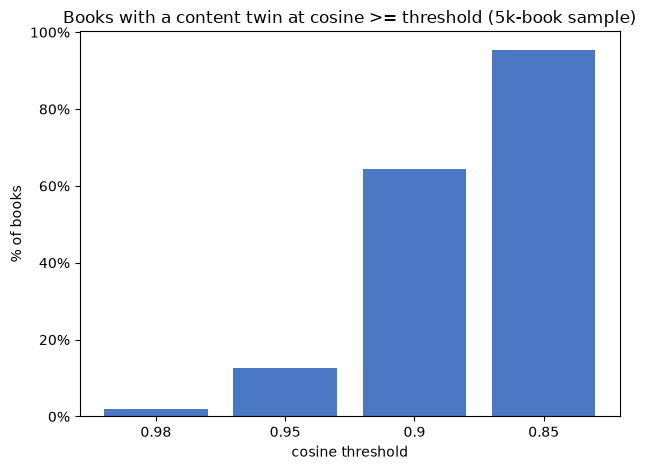

In [17]:
# --- Near-duplicate landscape: editions (title), series, and content twins ---
import re
from book_recsys.vecmath import l2_normalize

def _norm_title(t):
    t = re.sub(r"\(.*?\)", "", str(t))                       # drop "(Series, #1)" suffixes
    return re.sub(r"\s+", " ", re.sub(r"[^a-z0-9 ]", "", t.lower())).strip()

nt = catalog.title.map(_norm_title)
g = nt.groupby(nt).size(); dup = g[g > 1]
authkey = catalog.assign(nt=nt, a=catalog.author.fillna("")).groupby(["a", "nt"]).size()
print(f"books: {len(catalog):,}")
print(f"[editions] share a normalized title:      {dup.sum() / len(catalog):.1%}  (overcounts)")
print(f"[editions] same author + same base title: {authkey[authkey > 1].sum() / len(catalog):.1%}  (clean)")
print(f"[series]   title contains '#':            {catalog.title.str.contains('#', na=False).mean():.1%}")

emb = l2_normalize(np.load(find("embeddings.npy")).astype("float32"))   # content twins (5k sample)
rng = np.random.default_rng(0); idx = rng.choice(len(catalog), 5000, replace=False)
nn = np.empty(len(idx))
for s in range(0, len(idx), 250):
    q = idx[s:s + 250]; sims = emb[q] @ emb.T
    for j, qi in enumerate(q):
        sims[j, qi] = -1.0                                     # exclude self
    nn[s:s + 250] = sims.max(axis=1)
thr = [0.98, 0.95, 0.90, 0.85]; frac = [float((nn >= t).mean()) for t in thr]
print(f"[content] mean nearest-neighbour cosine: {nn.mean():.3f}")
for t, fr in zip(thr, frac):
    print(f"[content] twin at cosine >= {t}: {fr:.1%}")
plt.bar([str(t) for t in thr], frac, color="#4a78c4")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.title("Books with a content twin at cosine >= threshold (5k-book sample)")
plt.xlabel("cosine threshold"); plt.ylabel("% of books"); plt.tight_layout()

## Is bge-small the wrong model? (genre separation vs anisotropy)

The dense cosines above (mean nearest-neighbour 0.91) look alarming — but high *absolute* cosine isn't the same as poor discrimination. Two checks settle whether the embedding model is adequate for the task.

**1. Nearest-neighbour genre purity** — do a book's 10 nearest neighbours share its top (non-noise) genre?
- **41.5% do, vs a 4.5% random base-rate → ~9× lift.** The embeddings cluster strongly by content/genre, so they *rank* well. The model separates books — it's adequate for the task.

**2. Anisotropy** — sentence-transformer embeddings share a global direction that inflates all cosines. Subtracting the global mean vector (standard fix) collapses the baseline:
- mean NN cosine **0.91 → 0.66**; twin at ≥0.90 **64% → 3%**, at ≥0.95 **12% → 1%**.

→ **Conclusion:** the scary “everything is 0.9 similar” was **anisotropy + the shared template/shelf noise, not a wrong model.** bge-small encodes genre with a 9× lift, which is what matters for ranking. *Implications:* for de-dup / thresholds use **centered** embeddings (or rank-based cutoffs), not raw cosine; a bigger model (bge-large) is a quality *ablation*, not a fix for the cosine floor.

In [ ]:
# --- Is the embedding model adequate? genre-purity + anisotropy (mean-centering) ---
from collections import Counter
from book_recsys.vecmath import l2_normalize
from book_recsys.features.document import NOISE_SHELVES

raw = np.load(find("embeddings.npy")).astype("float32")
isl = lambda s: isinstance(s, (list, np.ndarray))
shelfsets = [set(s) if isl(s) else set() for s in catalog.shelves]
topg = [next((t for t in s if t not in NOISE_SHELVES), None) for s in shelfsets]  # first real genre
docf = Counter(); [docf.update(s) for s in shelfsets]
emb = l2_normalize(raw); rng = np.random.default_rng(0)

# (1) do a book's 10 nearest neighbours share its top genre?
cand = [i for i in range(len(catalog)) if topg[i]]
idx = rng.choice(cand, 2000, replace=False); pur, base = [], []
for s in range(0, len(idx), 200):
    q = idx[s:s + 200]; sims = emb[q] @ emb.T
    for j, qi in enumerate(q):
        sims[j, qi] = -1
        nn = [x for x in np.argpartition(-sims[j], 10)[:11] if x != qi][:10]
        pur.append(np.mean([topg[qi] in shelfsets[x] for x in nn])); base.append(docf[topg[qi]] / len(catalog))
pur, base = np.array(pur), np.array(base)
print(f"NN genre-purity: {pur.mean():.1%} share top genre vs {base.mean():.1%} random  -> {pur.mean()/base.mean():.1f}x lift")

# (2) anisotropy: nearest-neighbour cosine, raw vs mean-centered
def nn_cos(E):
    si = rng.choice(len(catalog), 5000, replace=False); v = np.empty(5000)
    for s in range(0, 5000, 250):
        q = si[s:s + 250]; sm = E[q] @ E.T
        for j, qi in enumerate(q): sm[j, qi] = -1
        v[s:s + 250] = sm.max(1)
    return v
raw_nn, cen_nn = nn_cos(emb), nn_cos(l2_normalize(raw - raw.mean(0)))
print(f"mean NN cosine  raw={raw_nn.mean():.3f}  centered={cen_nn.mean():.3f}")
thr = [0.95, 0.90, 0.85]; x = np.arange(len(thr))
plt.bar(x - 0.2, [(raw_nn >= t).mean() for t in thr], 0.4, label="raw", color="#d9534f")
plt.bar(x + 0.2, [(cen_nn >= t).mean() for t in thr], 0.4, label="mean-centered", color="#4a78c4")
plt.xticks(x, [str(t) for t in thr]); plt.legend()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.title("Twin-at-threshold: anisotropy inflates raw cosine (centering fixes it)")
plt.xlabel("cosine threshold"); plt.ylabel("% of books with a twin"); plt.tight_layout()

## Findings & anomalies

- **~54% of interactions are implicit (rating 0)** — explicit-only vs all-interactions is a real modeling fork (see the `filter_min_rating` ablation).
- **Heavy-tailed users** (median ~120, max ~68k interactions) and a **long-tail popularity** distribution over books — typical recsys skew; informs sampling/negatives.
- **Extremely sparse** user-book matrix (~0.04% dense) — motivates CF + content fusion.
- **~9% of books have empty descriptions** — content methods fall back to title + shelves for those.
- **Non-English books present** (language not filtered) — consider an English-only ablation.
- k-core floor visible: every user has ≥20 interactions, every book ≥10.